In [26]:
import scanpy as sc
import os
import bin2cell as b2c

In [2]:
## histogram and violin plots of average n_counts from spaceranger and bin_count from bin2cell

In [3]:
## filtering liver bin2cell outputs to have > 2 bin_count (being conservative)
## filtering heart 8 micron outputs to have 50 n_counts (to get rid of spots with 0 counts like in spaceranger output)

In [4]:
import re
import anndata as ad
import pandas as pd

In [5]:
import sys
print(sys.executable)

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/bin/python3.11


In [35]:
import matplotlib.pyplot as plt

In [22]:
b2c_dir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/'

In [6]:
samp_sheet = pd.read_csv('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/scripts/bin2cell/bin2cell_samp_md.txt',
                        sep='\t')

In [ ]:
adata_2725_b2c = sc.read_h5ad(f"{b2c_dir}{library_id}/{library_id}_cdata_b2c.h5ad")


In [21]:
samp_sheet = pd.read_csv('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/scripts/bin2cell/bin2cell_samp_md_reruns.txt',
                        sep='\t')

In [22]:
samp_sheet

,library_id,patient_id,condition,image_path,spaceranger_micron2_path,spaceranger_spatial_dir_path,mpp
0,QY_2645_1_2_3,HL180809,Normal,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
1,QY_2665_1_2,HL160029,Normal,/tscc/projects/ps-epigen/10x_output/Space_Rang...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
2,QY_2666_1_2,HL170058,MASH,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
3,QY_2673_1_2,HL230324,MASL,/tscc/projects/ps-epigen/10x_output/Space_Rang...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
4,QY_2674_1_2,HL230325,NASH_ALD,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
5,JL_104_2_3,HL221006,MASH,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
6,QY_2667_1_2,DVL9,CONTROL,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
7,QY_2668_1_2,DTX37-LVA,NICM_DM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
8,QY_2720_2,OC_LVA,NICM_DM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
9,QY_2721_2,T8_LVA,ICM_NDM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25


In [40]:
# only liver samples
samp_sheet_liver = samp_sheet[samp_sheet['library_id'].isin(['QY_2645_1_2_3',
                                                        'QY_2665_1_2', 'QY_2673_1_2', 'QY_2674_1_2', 'JL_104_2_3'
                                                        ])] # QY_2666_1_2
#  # JL_101_1_2_3, QY_2645_1_2_3, QY_2665_1_2, QY_2673_1_2, QY_2674_1_2

In [23]:
# only liver samples that were run later
samp_sheet_liver = samp_sheet[samp_sheet['library_id'].isin(['QY_2666_1_2'
                                                        ])] # QY_2666_1_2
#  # JL_101_1_2_3, QY_2645_1_2_3, QY_2665_1_2, QY_2673_1_2, QY_2674_1_2

In [24]:
samp_sheet_liver

,library_id,patient_id,condition,image_path,spaceranger_micron2_path,spaceranger_spatial_dir_path,mpp
2,QY_2666_1_2,HL170058,MASH,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25


In [28]:
outdir = '/tscc/projects/ps-epigen/users/cmiciano/Heart/outputs/sandbox/qc_plots_deep/'
b2c_dir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/'

In [30]:
os.makedirs(outdir, exist_ok = True)

In [32]:
def plot_qc_metrics_hist(anndata_obj, outdir, library_id, count_md):
    # Calculate the average counts per cell
    average_counts_per_cell = anndata_obj.obs[count_md].mean()
    # You can also visualize a histogram for a different representation
    plt.hist(anndata_obj.obs[count_md], bins=50)
    plt.axvline(average_counts_per_cell, color='r', linestyle='dashed', linewidth=2)
    plt.title('Distribution of Total Counts per Cell with Average')
    plt.xlabel('Total Counts')
    plt.ylabel('Frequency')
    #plt.ylim(0, 100)
    #plt.xlim(0, 500)
    
    #plt.show()
    
    plt.savefig(f"{outdir}{library_id}_hist_{count_md}.pdf")

In [33]:
def plot_qc_metrics_vln(anndata_obj, outdir, library_id, count_md):
    # Calculate the average counts per cell
    average_counts_per_cell = anndata_obj.obs[count_md].mean()
    
    # Print the average count
    print(f"Average counts per cell: {average_counts_per_cell}")
    
    
    # Calculate the average counts per cell
    median_counts_per_cell = anndata_obj.obs[count_md].median()

    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    num_cells = anndata_obj.n_obs
    #anndata_obj_ds = anndata_obj.copy()
    #sc.pp.subsample(anndata_obj_ds, n_obs=500000, random_state=42)
    
    sc.pl.violin(anndata_obj, ax=ax, keys=count_md, rotation=45, jitter=0.4, show = False)
    
    ax.axhline(average_counts_per_cell, color="red", linestyle="--", label=f"Mean: {average_counts_per_cell:.2f}")
    ax.axhline(median_counts_per_cell, color="purple", linestyle="--", label=f"Median: {median_counts_per_cell:.2f}")
    
    # Annotate the mean and median values
    ax.text(0.1, average_counts_per_cell, f"Mean: {average_counts_per_cell:.2f}", color="red", ha="center", va="center", backgroundcolor="white")
    ax.text(0.1, median_counts_per_cell, f"Median: {median_counts_per_cell:.2f}", color="purple", ha="center", va="center", backgroundcolor="white")
    
    # Display the legend
    ax.legend()
    
    # Show the plot
    #plt.show()
    
    
    # Add the number of cells as an annotation
    ax.text(0.95, 0.95, f'Number of Cells: {num_cells}', 
            transform=ax.transAxes, ha='right', va='top', color='black', fontsize=12)
    
    plt.savefig(f"{outdir}{library_id}_vlnplt_{count_md}.pdf")


Two micron path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2666_1_2_3/outs/binned_outputs/square_008um/
QY_2666_1_2
AnnData object with n_obs × n_vars = 771412 × 18035
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'labels_joint_source_colors', 'spatial'
    obsm: 'spatial', 'spatial_cropped'
Average counts per cell: 9.07822019880427


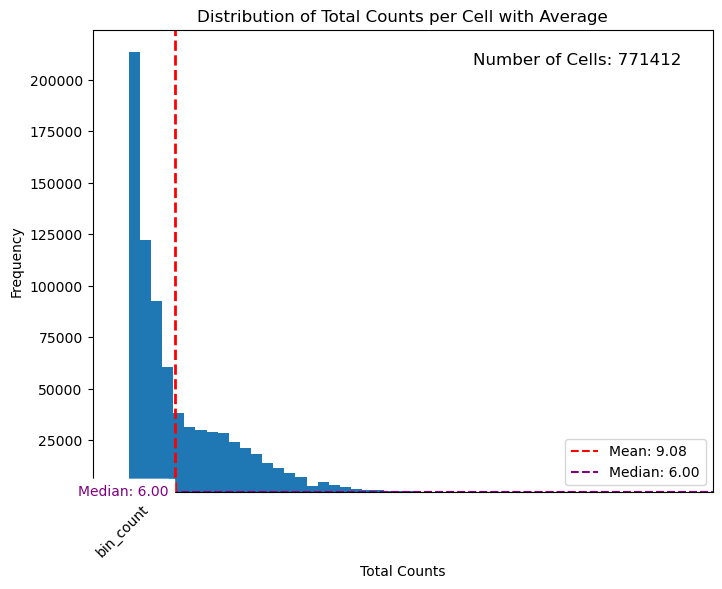

In [36]:
for index, row in samp_sheet_liver.iterrows():
    library_id = row['library_id']
    #print(f"Library ID: {library_id}")
          
    patient_id = row['patient_id']
    #print(f"Patient ID: {patient_id}")


    two_mic_path = row['spaceranger_micron2_path']
    two_mic_path = re.sub(f'square_002um', 'square_008um', two_mic_path)
    print(f"Two micron path: {two_mic_path}")

    img_path = row['image_path']
    #print(f"Image path: {img_path}")

    spatial_dir_path = row['spaceranger_spatial_dir_path']
    #print(f"Spat dir path: {spatial_dir_path}")

    
    
    #adata_2725 = b2c.read_visium(path =  two_mic_path,
    #                        source_image_path = img_path, 
    #                        spaceranger_image_path =  spatial_dir_path
    #                       )
    #adata_2725.var_names_make_unique()

    #sc.pp.filter_genes(adata_2725, min_cells=3)
    #sc.pp.filter_cells(adata_2725, min_counts=1)
    print(library_id)
    #print(adata_2725)

    #plot_qc_metrics_vln(adata_2725, outdir, library_id, 'n_counts')
    #plot_qc_metrics_hist(adata_2725, outdir, library_id, 'n_counts')

    adata_2725_b2c = sc.read_h5ad(f"{b2c_dir}{library_id}/{library_id}_cdata_b2c.h5ad")
    print(adata_2725_b2c)
    
    plot_qc_metrics_vln(adata_2725_b2c, outdir, library_id, 'bin_count')
    plot_qc_metrics_hist(adata_2725_b2c, outdir, library_id, 'bin_count')


In [45]:
os.mkdir('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/filt_deep/')

In [43]:
outdir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/filt_deep/'

In [39]:
outdir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/filt_deep/'

In [ ]:
# for liver used 2 bin ct

In [40]:
for index, row in samp_sheet_liver.iterrows():

    library_id = row['library_id']
    print(f"Library ID: {library_id}")

    ad_sp_b2c = sc.read_h5ad(f"{b2c_dir}{library_id}/{library_id}_cdata_b2c.h5ad")
    print(ad_sp_b2c)

    ad_sp_b2c_filt = ad_sp_b2c[ad_sp_b2c.obs['bin_count'] > 2].copy() #for liver used 2, 
    print(ad_sp_b2c_filt)
    print(ad_sp_b2c_filt.n_obs / ad_sp_b2c.n_obs)

    ad_sp_b2c_filt.write_h5ad(f"{outdir}{library_id}_cdata_b2c_filt_2ct.h5ad")
    


Library ID: QY_2666_1_2
AnnData object with n_obs × n_vars = 771412 × 18035
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'labels_joint_source_colors', 'spatial'
    obsm: 'spatial', 'spatial_cropped'
AnnData object with n_obs × n_vars = 557770 × 18035
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'labels_joint_source_colors', 'spatial'
    obsm: 'spatial', 'spatial_cropped'
0.7230507173857809


In [52]:
# only liver samples
samp_sheet_heart = samp_sheet[~samp_sheet['library_id'].isin(['QY_2645_1_2_3',
                                                        'QY_2665_1_2', 'QY_2673_1_2', 'QY_2674_1_2', 'JL_104_2_3', 'QY_2666_1_2'
                                                        ])] # QY_2666_1_2
#  # JL_101_1_2_3, QY_2645_1_2_3, QY_2665_1_2, QY_2673_1_2, QY_2674_1_2

In [53]:
samp_sheet_heart

,library_id,patient_id,condition,image_path,spaceranger_micron2_path,spaceranger_spatial_dir_path,mpp
6,QY_2667_1_2,DVL9,CONTROL,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
7,QY_2668_1_2,DTX37-LVA,NICM_DM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
8,QY_2720_2,OC_LVA,NICM_DM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
9,QY_2721_2,T8_LVA,ICM_NDM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
10,QY_2722_2,LM_LVA,NICM_NDM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
11,QY_2723_2,D47_LVA,CONTROL,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
12,QY_2724_2,FJ_LVA,NICM_NDM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
13,QY_2725_2,DWLVA,ICM_DM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
14,JL_105_2,SU_LVA,ICM_DM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
15,JL_106_2,TJ_LVA,ICM_NDM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25


In [54]:
outdir = '/tscc/projects/ps-epigen/users/cmiciano/Heart/outputs/sandbox/qc_plots_deep_heart/'


In [55]:
os.makedirs(outdir)

Two micron path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2667_1_2_3/outs/binned_outputs/square_008um/
Image path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/brightfield_images/DV9LVsmaller_20x_BF_01.tif
Spat dir path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2667_1_2_3/outs/spatial


anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


QY_2667_1_2
AnnData object with n_obs × n_vars = 254923 × 15231
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
Average counts per cell: 77.51611328125
Two micron path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2668_1_2_3/outs/binned_outputs/square_008um/
Image path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/brightfield_images/DTX374.smaller_20x_BF_01.tif
Spat dir path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2668_1_2_3/outs/spatial


anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


QY_2668_1_2
AnnData object with n_obs × n_vars = 442734 × 16238
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
Average counts per cell: 55.03754806518555
Two micron path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2720_2_3/outs/binned_outputs/square_008um/
Image path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/brightfield_images/OC_LVAflipped.tif
Spat dir path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2720_2_3/outs/spatial


...

QY_2725_2
AnnData object with n_obs × n_vars = 427141 × 16788
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
Average counts per cell: 119.32703399658203
Two micron path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/JL_105_2_3/outs/binned_outputs/square_008um/
Image path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/brightfield_images/SU_LVA.flipped.tif
Spat dir path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/JL_105_2_3/outs/spatial


anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


JL_105_2
AnnData object with n_obs × n_vars = 228774 × 15888
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
Average counts per cell: 73.48355865478516
Two micron path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/JL_106_2_3/outs/binned_outputs/square_008um/
Image path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/brightfield_images/TJ_LVA.flipped.tif
Spat dir path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/JL_106_2_3/outs/spatial


anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


JL_106_2
AnnData object with n_obs × n_vars = 333927 × 15756
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
Average counts per cell: 148.12496948242188


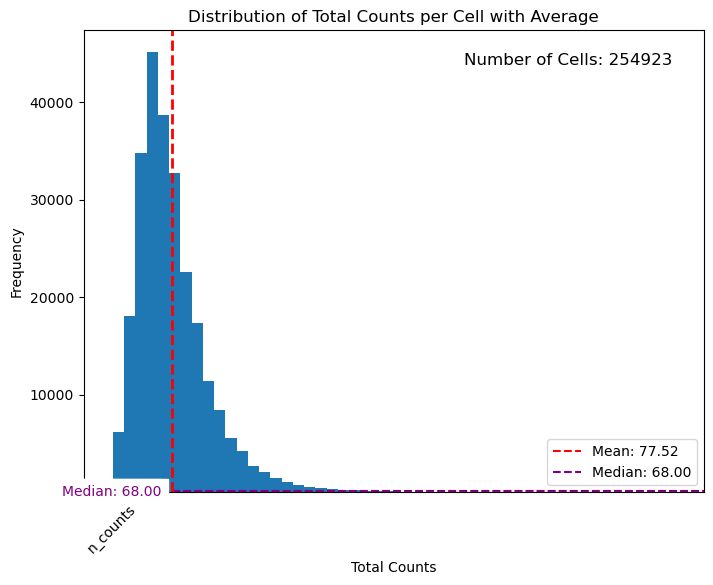

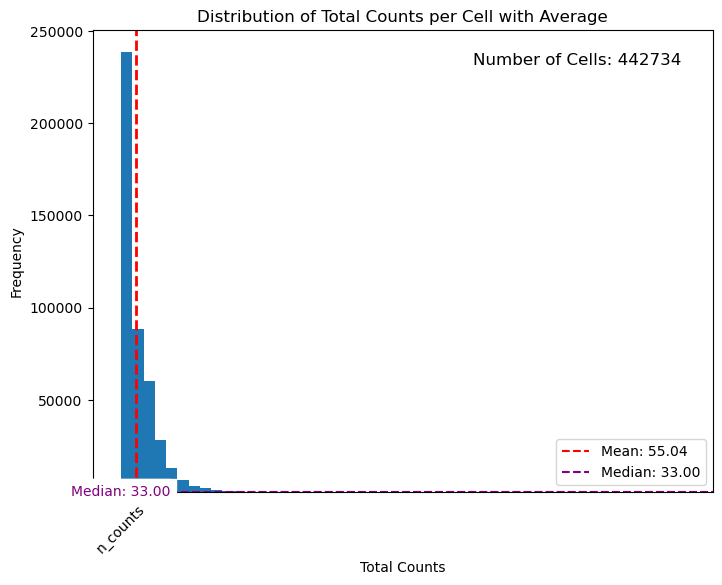

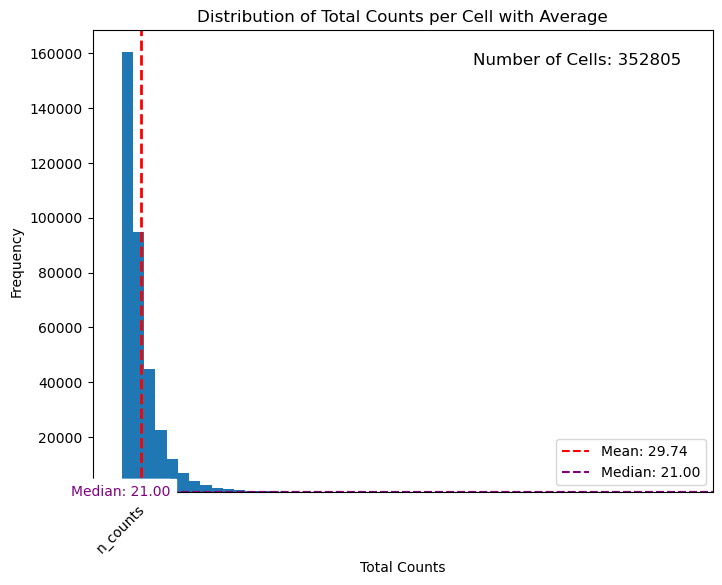

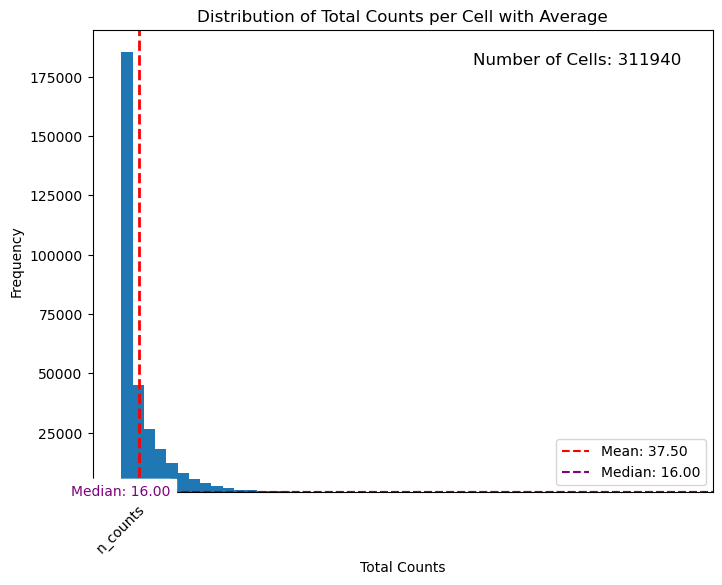

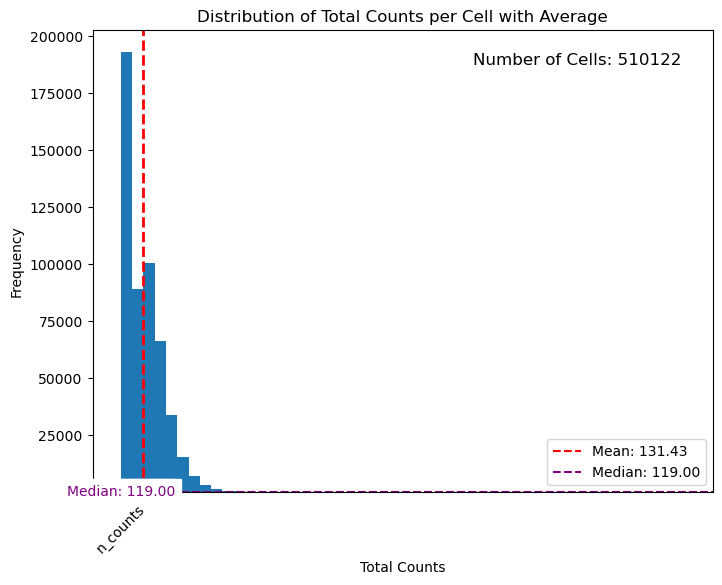

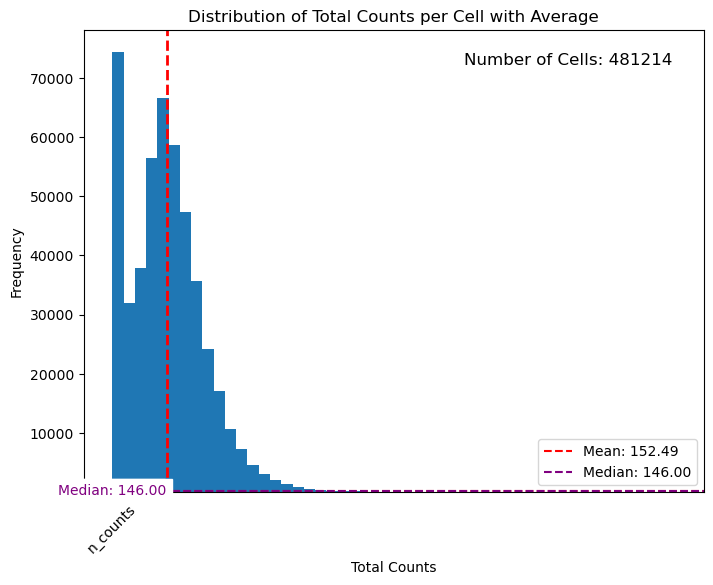

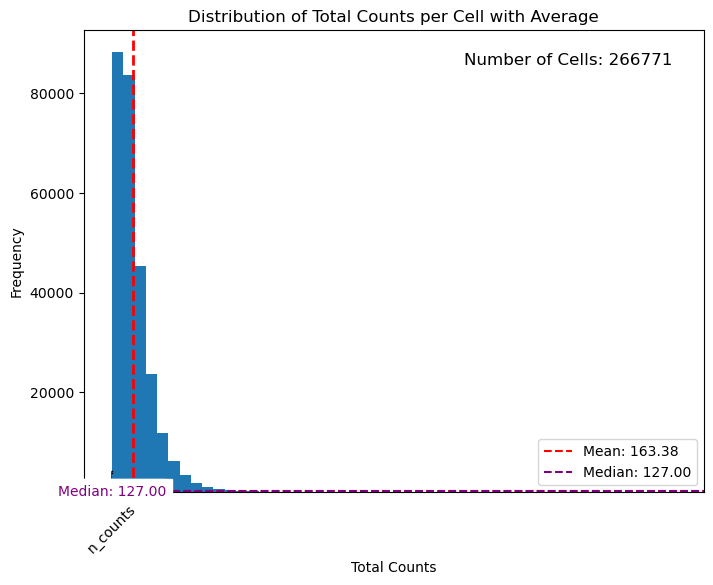

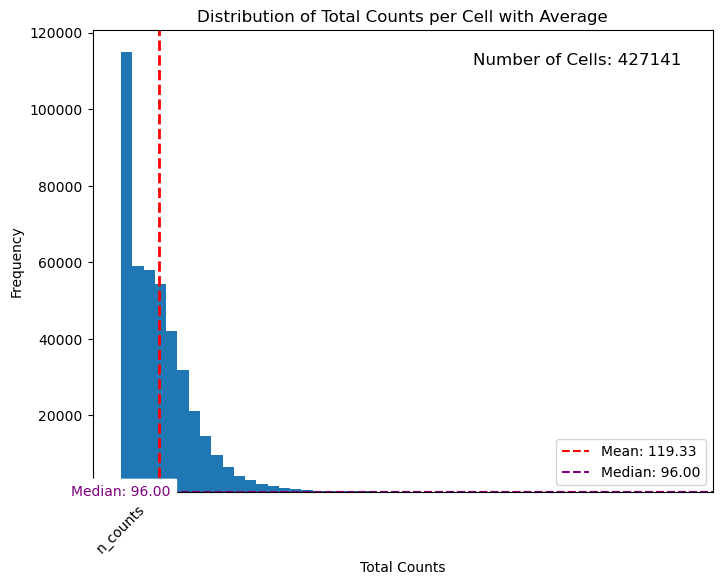

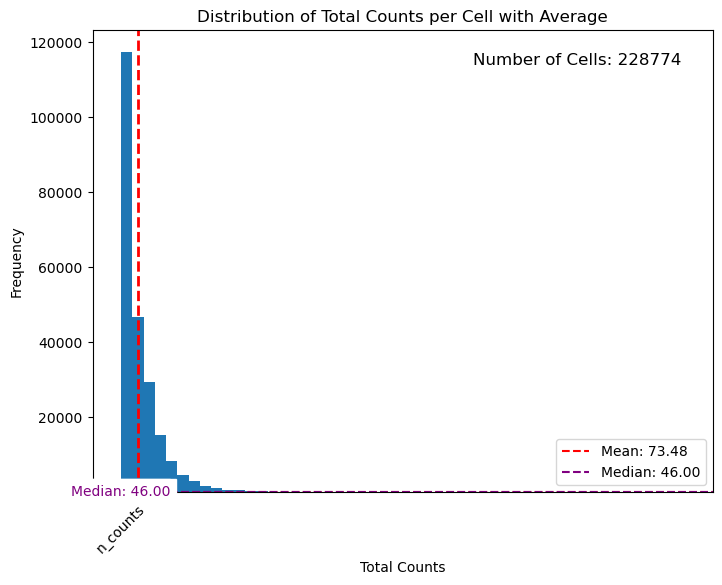

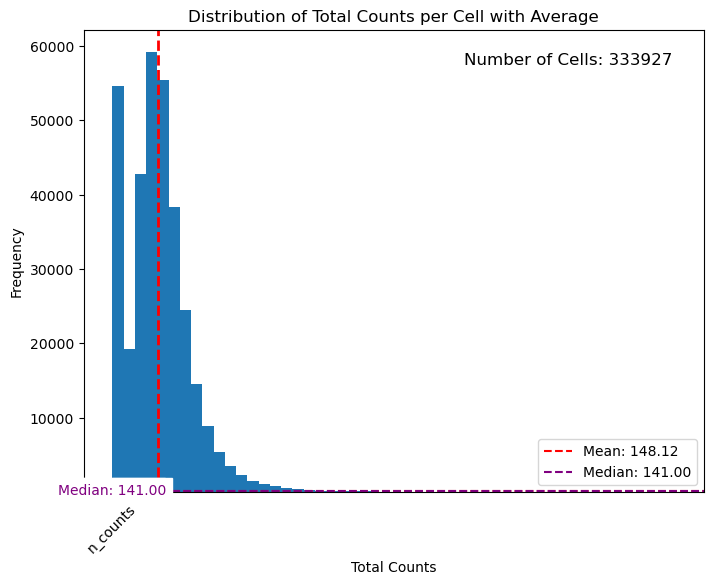

In [58]:
for index, row in samp_sheet_heart.iterrows():
    library_id = row['library_id']
    #print(f"Library ID: {library_id}")
          
    patient_id = row['patient_id']
    #print(f"Patient ID: {patient_id}")


    two_mic_path = row['spaceranger_micron2_path']
    two_mic_path = re.sub(f'square_002um', 'square_008um', two_mic_path)
    print(f"Two micron path: {two_mic_path}")

    img_path = row['image_path']
    print(f"Image path: {img_path}")

    spatial_dir_path = row['spaceranger_spatial_dir_path']
    print(f"Spat dir path: {spatial_dir_path}")

    
    
    adata_2725 = b2c.read_visium(path =  two_mic_path,
                            source_image_path = img_path, 
                            spaceranger_image_path =  spatial_dir_path
                           )
    adata_2725.var_names_make_unique()

    sc.pp.filter_genes(adata_2725, min_cells=3)
    sc.pp.filter_cells(adata_2725, min_counts=1)
    print(library_id)
    print(adata_2725)

    plot_qc_metrics_vln(adata_2725, outdir, library_id, 'n_counts')
    plot_qc_metrics_hist(adata_2725, outdir, library_id, 'n_counts')

    #adata_2725_b2c = sc.read_h5ad(f"{b2c_dir}{library_id}/{library_id}_cdata_b2c.h5ad")
    #print(adata_2725_b2c)
    
    #plot_qc_metrics_vln(adata_2725_b2c, outdir, library_id, 'bin_count')
    #plot_qc_metrics_hist(adata_2725_b2c, outdir, library_id, 'bin_count')


In [59]:
samp_sheet_heart

,library_id,patient_id,condition,image_path,spaceranger_micron2_path,spaceranger_spatial_dir_path,mpp
6,QY_2667_1_2,DVL9,CONTROL,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
7,QY_2668_1_2,DTX37-LVA,NICM_DM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
8,QY_2720_2,OC_LVA,NICM_DM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
9,QY_2721_2,T8_LVA,ICM_NDM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
10,QY_2722_2,LM_LVA,NICM_NDM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
11,QY_2723_2,D47_LVA,CONTROL,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
12,QY_2724_2,FJ_LVA,NICM_NDM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
13,QY_2725_2,DWLVA,ICM_DM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
14,JL_105_2,SU_LVA,ICM_DM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25
15,JL_106_2,TJ_LVA,ICM_NDM,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,/tscc/projects/ps-epigen/users/cmiciano/Liver/...,0.25


In [60]:
os.mkdir('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/filt_deep_heart/')

In [61]:
outdir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/filt_deep_heart/'

In [63]:
adata_2725

AnnData object with n_obs × n_vars = 254923 × 15231
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'

In [64]:
for index, row in samp_sheet_heart.iterrows():
    library_id = row['library_id']
    #print(f"Library ID: {library_id}")
          
    patient_id = row['patient_id']
    #print(f"Patient ID: {patient_id}")


    two_mic_path = row['spaceranger_micron2_path']
    two_mic_path = re.sub(f'square_002um', 'square_008um', two_mic_path)
    print(f"Two micron path: {two_mic_path}")

    img_path = row['image_path']
    print(f"Image path: {img_path}")

    spatial_dir_path = row['spaceranger_spatial_dir_path']
    print(f"Spat dir path: {spatial_dir_path}")

    
    
    adata_2725 = b2c.read_visium(path =  two_mic_path,
                            source_image_path = img_path, 
                            spaceranger_image_path =  spatial_dir_path
                           )
    adata_2725.var_names_make_unique()

    sc.pp.filter_genes(adata_2725, min_cells=3)
    sc.pp.filter_cells(adata_2725, min_counts=1)
    print(library_id)
    print(adata_2725)

    adata_2725_filt = adata_2725[adata_2725.obs['n_counts'] > 50].copy() #for liver used 2, 
    print(adata_2725_filt)
    print(adata_2725_filt.n_obs / adata_2725_filt.n_obs)

    adata_2725_filt.write_h5ad(f"{outdir}{library_id}_cdata_8mic_filt_50ct.h5ad")
    


Two micron path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2667_1_2_3/outs/binned_outputs/square_008um/
Image path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/brightfield_images/DV9LVsmaller_20x_BF_01.tif
Spat dir path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2667_1_2_3/outs/spatial


anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


QY_2667_1_2
AnnData object with n_obs × n_vars = 254923 × 15231
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 178148 × 15231
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
1.0
Two micron path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2668_1_2_3/outs/binned_outputs/square_008um/
Image path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/brightfield_images/DTX374.smaller_20x_BF_01.tif
Spat dir path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2668_1_2_3/outs/spatial


anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


QY_2668_1_2
AnnData object with n_obs × n_vars = 442734 × 16238
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 185310 × 16238
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
1.0
Two micron path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2720_2_3/outs/binned_outputs/square_008um/
Image path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/brightfield_images/OC_LVAflipped.tif
Spat dir path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/QY_2720_2_3/outs/spatial


...

QY_2725_2
AnnData object with n_obs × n_vars = 427141 × 16788
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 288032 × 16788
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
1.0
Two micron path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/JL_105_2_3/outs/binned_outputs/square_008um/
Image path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/brightfield_images/SU_LVA.flipped.tif
Spat dir path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/JL_105_2_3/outs/spatial


anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


JL_105_2
AnnData object with n_obs × n_vars = 228774 × 15888
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 109247 × 15888
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
1.0
Two micron path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/JL_106_2_3/outs/binned_outputs/square_008um/
Image path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/brightfield_images/TJ_LVA.flipped.tif
Spat dir path: /tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/spaceranger/JL_106_2_3/outs/spatial


anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


JL_106_2
AnnData object with n_obs × n_vars = 333927 × 15756
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 273939 × 15756
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
1.0


In [1]:
import scanpy as sc

In [3]:
test = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Heart/outputs/tangram/20241105_tangram_preprocessing_genelist50_ctrl/Preprocessed_adsc.h5ad')

In [4]:
test

AnnData object with n_obs × n_vars = 20000 × 36510
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.2', 'seurat_clusters', 'log_nCount_ATAC', 'log_nCount_SCT', 'log_nFeature_ATAC', 'log_nFeature_SCT', 'wsnn_res.0.25', 'library', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fra

In [5]:
test.obs['cell.major_types'].value_counts()

cell.major_types
vCM            11407
Fibroblast      2493
Endothelial     2365
Pericyte        1697
Myeloid          959
Lymphoid         601
SM               222
Neuronal         182
Endocardial       59
Adipocyte         13
Epicardial         2
Name: count, dtype: int64

In [6]:
os.mkdir('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/filt/')

In [ ]:

# Function to extract patient ID from file path
def extract_patient_id(file_path):
    # Match pattern for patient ID based on the directory structure
    match = re.search(r'bin2cell_array_cpu/(.+?)/', file_path)
    if match:
        return match.group(1)
    else:
        raise ValueError("Patient ID not found in the path")

# Function to process .h5ad files
def process_h5ad(file_path, output_dir, count_threshold):
    # Extract patient ID
    patient_id = extract_patient_id(file_path)
    print(f"Processing patient ID: {patient_id}")

    # Read the .h5ad file
    adata = ad.read_h5ad(file_path)

    # Filter cells based on counts (example: total counts in obs)
    adata_filtered = adata[adata.obs["total_counts"] > count_threshold]

    # Define output file name
    output_file = os.path.join(output_dir, f"{patient_id}_filtered.h5ad")
    
    # Write the filtered data to a new .h5ad file
    adata_filtered.write(output_file)
    print(f"Filtered file saved to: {output_file}")

# Directory with .h5ad files
input_dir = "/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/outputs/sandbox/spatial/bin2cell_array_cpu/"
output_dir = "/path/to/output/files"
count_threshold = 1000  # Example threshold

# Iterate over .h5ad files and process them
for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith(".h5ad"):
            file_path = os.path.join(root, file)
            process_h5ad(file_path, output_dir, count_threshold)